Práctica 1: Slant Range, Tiempo rápido y Factor RANK.
Para esta práctica voy necesitar datos de Altura SAOCOM y la tabla de definición de productos de la página:  https://catalogos.conae.gov.ar/catalogo/catalogoSaocomdocs.html

Malargue

Latitud: -35.47°
Orbit time (Lat): ~ 3500 s
H (Lat): 635 km

In [ ]:
import numpy as np

# ====================================================================
# PRÁCTICA 1: Geometría de Adquisición y RANK
# ====================================================================
# INSTRUCCIÓN: Busca en graficos, tablas y metadato los valores necesarios.

C = 299792458.0       # Constante: Velocidad de la luz [m/s]

# --- Completar a partir de aquí ---
H = 635*1000            # Altura orbital del satélite [m] (Ver graficas SAOCOM)
# <AcquisitionMode>STRIPMAP</AcquisitionMode>; <Swath>DS6</Swath>
inc_angle_near = 41.3 # Ángulo de incidencia Near [grados] (Ver tabla SAOCOM)
inc_angle_far = 44.5  # Ángulo de incidencia Far [grados] (Ver tabla SAOCOM)
# <AcquisitionPRF>1886</AcquisitionPRF>
PRF = 1886         # Tasa de repetición de pulsos [Hz] (Buscar en metadato)

# 1. Cálculo de Slant Range (Distancia de visión inclinada)
theta_near_rad = np.radians(inc_angle_near)
theta_far_rad = np.radians(inc_angle_far)

R_near = H/np.cos(theta_near_rad)          # Usar aprox tierra plana
R_far = H/np.cos(theta_far_rad)

# 2. Cálculo del Tiempo Rápido (Two-way travel time)
# El tiempo que tada el pulso en ir hasta el blanco y volver
t_near = (R_near/C)*2
t_far = (R_far/C)*2

# 3. Cálculo del PRI y Factor RANK
PRI = 1 / PRF

# Factor RANK: ¿Cuántos pulsos están "volando" simultáneamente?
# Se calcula como la división entera entre el tiempo de vuelo y el PRI
# NOTA: Cantidad de pulsos que se pueden emitir entre el primer pulso que se emite, y el primero que se recibe
# depende del R y el PRI. Si varía entre near y far, se toma el más pequeño. 
rank_near = int(t_near / PRI)
rank_far = int(t_far / PRI)

# --- Resultados ---
print(f"--- RESULTADOS CÁLCULO 1 ---")
print(f"Slant Range Near:   {R_near/1000:.2f} km")
print(f"Slant Range Far:    {R_far/1000:.2f} km")
print(f"Tiempo rápido Near: {t_near*1000:.2f} milisegundos")
print(f"Tiempo rápido Far:  {t_far*1000:.2f} milisegundos")
print(f"PRI (Latido):       {PRI*1000:.2f} milisegundos")
print(f"Factor RANK (Near): {rank_near}")
print(f"Factor RANK (Far):  {rank_far}")

--- RESULTADOS CÁLCULO 1 ---
Slant Range Near:   845.24 km
Slant Range Far:    890.29 km
Tiempo rápido Near: 5.64 milisegundos
Tiempo rápido Far:  5.94 milisegundos
PRI (Latido):       0.53 milisegundos
Factor RANK (Near): 10
Factor RANK (Far):  11


Práctica 2: Resolución en rango y ancho de pisada (Swath Width)

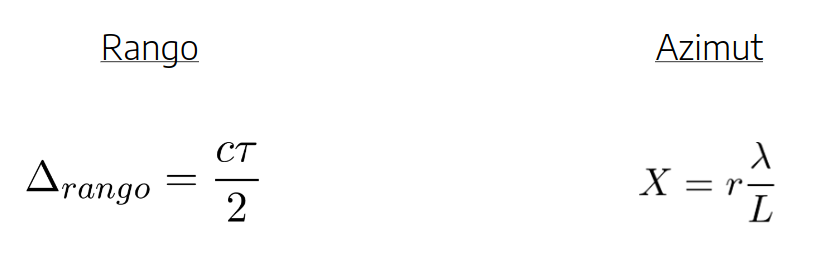


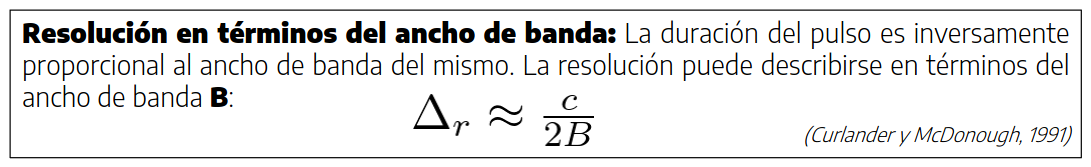
La resolución depende del Bandwidth, ya que a mayor ancho de banda, puedo almacenar más información


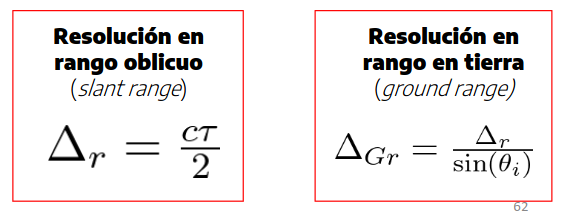

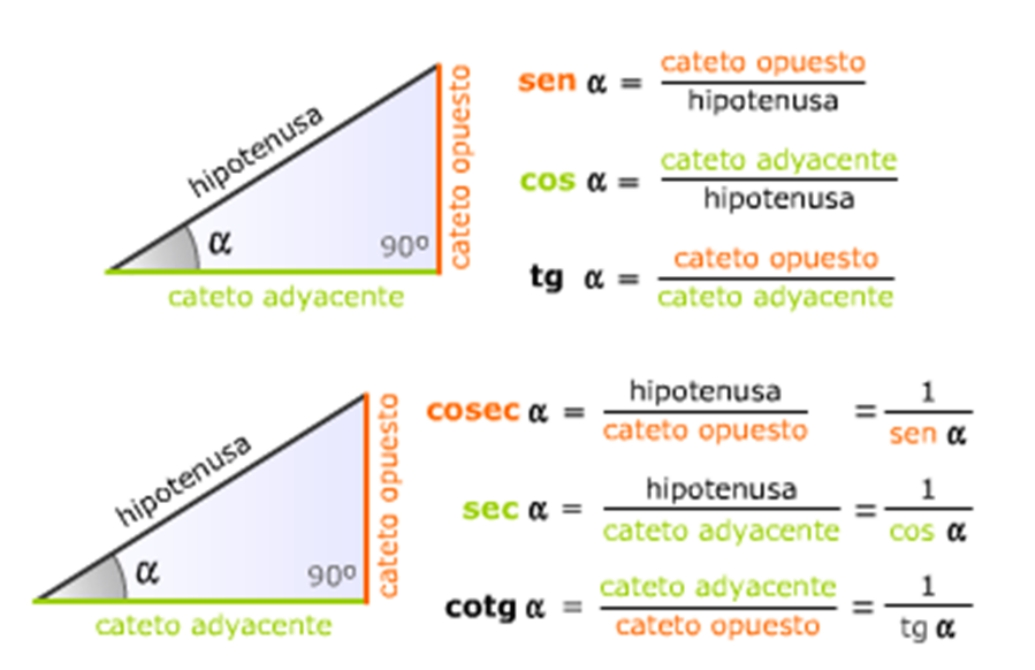

In [3]:
# ====================================================================
# PRÁCTICA 2: Resolución y Ancho de Pisada (Swath Width)
# ====================================================================
# INSTRUCCIÓN: Busca en el metadato el Ancho de Banda (Bandwidth)
# y la frecuencia de muestreo o Sampling frequency.

# --- Completar a partir de aquí ---
# <Bandwidth unit="Hz">20600000</Bandwidth>
Bw = 20600000               # Ancho de banda / Bandwidth [Hz]
# <PulseSamplingRate unit="Hz">30000000</PulseSamplingRate>
fs = 30000000              # Frecuencia de muestreo / Sampling frequency [Hz]
# NOTA: Bw no puede ser menor que Bw

pixel_spacing_rg = C / (2 * fs) # Espaciado del píxel en rango [m]

# 1. Resolución Teórica en Slant Range
res_slant_range = C / (2 * Bw)

# 2. Resolución proyectada al terreno (Ground Range)
res_ground_near = res_slant_range/np.sin(theta_near_rad)
res_ground_far = res_slant_range/np.sin(theta_far_rad)

# 3. Ancho de la pisada (Swath Width) en Slant Range
swath_slant = R_far - R_near

# 4. Ancho de la pisada (Swath Width) en Ground Range
# Usar trigonometría con aproximación tierra plana
ground_range_near = R_near-np.cos(np.radians(360-90)-theta_near_rad)
ground_range_far = R_far-np.cos(np.radians(360-90)-theta_far_rad)
swath_ground = ground_range_far - ground_range_near


# --- Resultados ---
print(f"--- RESULTADOS PRACTICA 2 ---")
print(f"Resolución teórica (Slant Range):   {res_slant_range:.2f} m")
print(f"Pixel Spacing (Slant Range):        {pixel_spacing_rg:.2f} m")
print(f"---")
print(f"Resolución en el terreno (Near):    {res_ground_near:.2f} m")
print(f"Resolución en el terreno (Far):     {res_ground_far:.2f} m")
print(f"---")
print(f"Ancho de la pisada (Slant Swath):   {swath_slant/1000:.2f} km")
print(f"Ancho de la pisada (Ground Swath):  {swath_ground/1000:.2f} km")

--- RESULTADOS PRACTICA 2 ---
Resolución teórica (Slant Range):   7.28 m
Pixel Spacing (Slant Range):        5.00 m
---
Resolución en el terreno (Near):    11.02 m
Resolución en el terreno (Far):     10.38 m
---
Ancho de la pisada (Slant Swath):   45.05 km
Ancho de la pisada (Ground Swath):  45.05 km


PRACTICA 3: Resolución y pixel spacing en azimuth. Largo de pisada (Swath length)

In [ ]:
# ====================================================================
# PRÁCTICA 3: Azimut, RAR vs SAR y Largo de Imagen
# ====================================================================
# INSTRUCCIÓN: Busca en el metadato la Frecuencia Central,
# la longitud de la antena, velocidad aprox del satélite en esa latitud, PRF y la cantidad de líneas(Lines).

# --- Completar a partir de aquí ---
# <fc_hz unit="Hz">1275000000</fc_hz>
fc = 1275000000            # Frecuencia central (Banda L) [Hz]
La = 10               # Longitud física de la antena [m]
Vs =  7615             # Velocidad de la señal [m/s]
PRF = 1886         # Tasa de repetición de pulsos [Hz]

# La imagen cruda es una matriz de pulsos (lines) y muestras (samples)
#<Lines>16974</Lines>
# <Samples>8704</Samples>
lines = 16974           # Número de líneas (filas) en la imagen

# 1. Parámetros previos
pixel_spacing_az = Vs / PRF # Valor teórico de distancia entre píxeles 
wl = C / fc                       # Longitud de onda [m]
R_mid = (R_near + R_far)/2            # Distancia promedio al centro de la imagen [m]

# 2. Resolución en Azimut sin procesar (Radar de Apertura Real - RAR)
res_azimuth_rar = R_mid*wl/La

# 3. Resolución en Azimut procesada (Radar de Apertura Sintética - SAR)
res_azimuth_sar = La / 2

# 4. Largo total de la pisada en la dirección de vuelo
largo_imagen = lines * pixel_spacing_az
 
# --- Resultados ---
print(f"--- RESULTADOS PRACTICA 3 ---")
print(f"Longitud de onda (Banda L):         {wl:.2f} m")
print(f"---")
print(f"Resolución de antena física (RAR):  {res_azimuth_rar:.2f} m")
print(f"Resolución de antena virtual (SAR): {res_azimuth_sar:.2f} m")
print(f"Pixel Spacing en Azimuth:           {pixel_spacing_az:.2f} m")
print(f"Largo total de la imagen adquirida: {largo_imagen/1000:.2f} km")
print(f"¿Cuál es el largo de la imagen en Ground SAOCOM? Medirlo en Google Earth")
print(f"---")

--- RESULTADOS PRACTICA 3 ---
Longitud de onda (Banda L):         0.24 m
---
Resolución de antena física (RAR):  20403.90 m
Resolución de antena virtual (SAR): 5.00 m
Pixel Spacing en Azimuth:           4.04 m
Largo total de la imagen adquirida: 68.53 km
¿Cuál es el largo de la imagen en Ground SAOCOM? Medirlo en Google Earth
---
